# Exploring FreshRetailNet-50K: 50-store subset

All figures here come from `data/frn/stores_50`, created by `python scripts/download_frn.py` (50 stores, seed 42).

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

train = pd.read_parquet("data/frn/stores_50/train.parquet")
train["dt"] = pd.to_datetime(train["dt"])
print(train.shape)
train.head()

Matplotlib is building the font cache; this may take a moment.


(237060, 19)


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,0,95,0,5,5,6,768,2024-03-28,0.3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.559000,0,1,1.3444,15.62,80.57,1.16
1,0,95,0,5,5,6,768,2024-03-29,0.1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.661000,0,1,2.6676,15.01,82.60,1.46
2,0,95,0,5,5,6,768,2024-03-30,0.1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",11,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",0.661000,1,1,1.7482,16.19,81.35,1.70
3,0,95,0,5,5,6,768,2024-03-31,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",16,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.661017,1,1,1.1834,16.17,82.41,1.47
4,0,95,0,5,5,6,768,2024-04-01,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",16,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1.000000,0,0,3.4215,15.62,82.83,1.27


In [3]:
series_keys = ["store_id", "product_id"]
rows_per_series = train.groupby(series_keys).size()
print(f"{rows_per_series.size} series, rows per series: {rows_per_series.unique()}")
print(train["dt"].min().date(), "to", train["dt"].max().date())
print(f"{train['store_id'].nunique()} stores, {train['product_id'].nunique()} products")

2634 series, rows per series: [90]
2024-03-28 to 2024-06-25
50 stores, 437 products


## Does hours_stock_status = 1 mean out of stock?

In [5]:
status = np.stack(train["hours_stock_status"].to_numpy())
hourly_sales = np.stack(train["hours_sale"].to_numpy())
out_hours_6_to_21 = status[:, 6:22].sum(axis=1)
matches = out_hours_6_to_21 == train["stock_hour6_22_cnt"].to_numpy()
print(f"Rows where the 1s in hours 6-21 match stock_hour6_22_cnt: {matches.mean():.2%}")
print(
    "Hourly sales add up to daily sales:",
    np.allclose(hourly_sales.sum(axis=1), train["sale_amount"]),
)

Rows where the 1s in hours 6-21 match stock_hour6_22_cnt: 100.00%
Hourly sales add up to daily sales: True


In [6]:
trading_out = status[:, 6:22] == 1
trading_sales = hourly_sales[:, 6:22]
print(f"Mean hourly sales, in stock:     {trading_sales[~trading_out].mean():.4f}")
print(f"Mean hourly sales, out of stock: {trading_sales[trading_out].mean():.4f}")
print(
    f"Days with a stockout in trading hours: {(train['stock_hour6_22_cnt'] > 0).mean():.1%}"
)
print(f"Days with zero sales: {(train['sale_amount'] == 0).mean():.1%}")

Mean hourly sales, in stock:     0.0709
Mean hourly sales, out of stock: 0.0050
Days with a stockout in trading hours: 44.1%
Days with zero sales: 4.4%


In [8]:
print(f"Trading hours out of stock: {trading_out.mean():.1%}")
zero_sales = train["sale_amount"] == 0
full_day_out = train["stock_hour6_22_cnt"] == 16
print(
    f"Zero-sales days that were out of stock all day: {full_day_out[zero_sales].mean():.1%}"
)
train["stock_hour6_22_cnt"].value_counts(normalize=True).sort_index().round(3)

Trading hours out of stock: 19.8%
Zero-sales days that were out of stock all day: 73.1%


stock_hour6_22_cnt
0     0.559
1     0.031
2     0.026
3     0.031
4     0.045
5     0.054
6     0.046
7     0.032
8     0.025
9     0.023
10    0.024
11    0.025
12    0.018
13    0.012
14    0.006
15    0.003
16    0.039
Name: proportion, dtype: float64

## Weekly pattern, discounts and the hourly sales profile

In [9]:
weekday_mean = train.groupby(train["dt"].dt.day_name())["sale_amount"].mean()
print(weekday_mean.sort_values(ascending=False).round(3))

series_promo_means = (
    train.assign(on_promo=train["discount"] < 1)
    .groupby(series_keys + ["on_promo"])["sale_amount"]
    .mean()
    .unstack("on_promo")
)
lift = (
    (series_promo_means[True] / series_promo_means[False])
    .replace(np.inf, np.nan)
    .dropna()
)
print(
    f"Median sales lift on discount days, within series: {lift.median():.2f}x across {lift.size} series"
)

dt
Sunday       1.164
Saturday     1.149
Tuesday      0.930
Monday       0.911
Friday       0.907
Wednesday    0.885
Thursday     0.845
Name: sale_amount, dtype: float64
Median sales lift on discount days, within series: 1.37x across 2431 series


Share of daily sales from 15:00 onwards: 41.1%


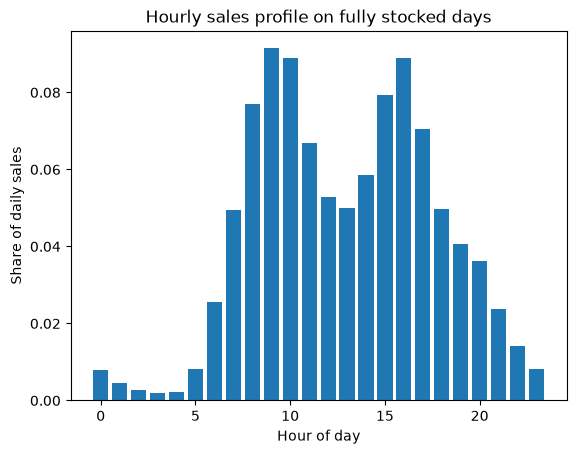

In [10]:
fully_stocked = (train["stock_hour6_22_cnt"] == 0).to_numpy() & (
    train["sale_amount"] > 0
).to_numpy()
profile = hourly_sales[fully_stocked].sum(axis=0) / hourly_sales[fully_stocked].sum()
print(f"Share of daily sales from 15:00 onwards: {profile[15:].sum():.1%}")
plt.bar(range(24), profile)
plt.xlabel("Hour of day")
plt.ylabel("Share of daily sales")
plt.title("Hourly sales profile on fully stocked days")
plt.show()

## Findings

- A value of 1 in `hours_stock_status` means out of stock. Counting the 1s between 06:00 and 21:59 reproduces `stock_hour6_22_cnt` on every row. Mean hourly sales are 0.0050 in hours flagged out of stock, against 0.0709 in stocked hours.
- 19.8% of trading hours are out of stock, which matches the dataset card's figure of about 20%. Measured in days, 44.1% of store-product-days have at least one out-of-stock trading hour.
- Most stockouts are partial. 55.9% of days are fully stocked and 3.9% are out of stock all day, so the remaining days run out for between 1 and 15 trading hours.
- Zero sales usually mean no stock rather than no demand: 73.1% of zero-sales days were out of stock for all 16 trading hours. Only 4.4% of days have zero sales at all.
- Weekends sell more. In the dataset's normalised units, mean daily sales are 1.164 on Sunday and 1.149 on Saturday, against 0.845 to 0.930 on weekdays.
- Within the same series, days with a discount have a median of 1.37 times the sales of days without one, across the 2,431 series that had both kinds of day. Discount days may overlap with other effects such as activity days, so this is an association rather than a measured causal effect.
- Sales peak around 09:00 and again around 16:00, and 41.1% of a fully stocked day's sales come from 15:00 onwards. Sales continue at a low level overnight, which fits the dataset card's description of each store as a warehouse.

The stockout correction has to run before any model is trained, because on 44.1% of days recorded sales can understate demand. Partial stockouts can be corrected with the hourly profile above. Full-day stockouts have no sales to scale up and need separate handling.